In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import iqr
from sklearn.linear_model import LinearRegression
import numpy as np

In [2]:
df = pd.read_csv('../data/HKHJ_Dataset_Prepared.csv', )

In [3]:
df.head()

,date,location,race_no,info,going,course,sec1,sec2,sec3,sec4,...,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds
0,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",24.31,47.78,72.34,95.78,...,5.6,1,264,Class 4,1600,60-40,TURF,2,1.0,95.78
1,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",24.31,47.78,72.34,95.78,...,15.0,1,264,Class 4,1600,60-40,TURF,2,2.0,95.81
2,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",24.31,47.78,72.34,95.78,...,3.6,1,264,Class 4,1600,60-40,TURF,2,3.0,96.04
3,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",24.31,47.78,72.34,95.78,...,8.4,1,264,Class 4,1600,60-40,TURF,2,4.0,96.07
4,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",24.31,47.78,72.34,95.78,...,9.5,1,264,Class 4,1600,60-40,TURF,2,5.0,96.41


In [4]:
df.shape

(158563, 33)

In [5]:
print(df.dtypes)

date                        str
location                    str
race_no                     str
info                        str
going                       str
course                      str
sec1                    float64
sec2                    float64
sec3                    float64
sec4                    float64
sec5                    float64
sec6                    float64
place                       str
horse_number            float64
horse_name                  str
jockey                      str
trainer                     str
weight                    int64
on_date_horse_weight    float64
draw                    float64
length_behind_winner    float64
running_position            str
finish_time                 str
win_odds                float64
race_id_number            int64
race_id_year              int64
info_class                  str
info_distance             int64
info_rating                 str
surface_type                str
rail_offset               int64
place_nu

In [6]:
df[df.duplicated()].shape

(0, 33)

No duplicates in the dataset, so no need to drop anything

In [7]:
df.isnull().sum()

date                         0
location                     0
race_no                      0
info                         0
going                        0
course                       0
sec1                         0
sec2                         0
sec3                         0
sec4                     71243
sec5                    139489
sec6                    155992
place                        0
horse_number              1608
horse_name                   0
jockey                       0
trainer                      0
weight                       0
on_date_horse_weight      2967
draw                      2958
length_behind_winner      3399
running_position             0
finish_time                  0
win_odds                  2967
race_id_number               0
race_id_year                 0
info_class                   0
info_distance                0
info_rating               6920
surface_type                 0
rail_offset                  0
place_numeric             3287
finish_t

The columns sec4-sec6 have a lot of missing values. Some races are longer and therefore have more sections, while the shortest races only consist of 3 races.
Lets take a closer look and see how to handle this.

In [8]:
df_secs = df[['sec1', 'sec2', 'sec3', 'sec4', 'sec5', 'sec6']].copy()
sections = ['sec1', 'sec2', 'sec3', 'sec4', 'sec5', 'sec6']
df_secs['last_section_name'] = df_secs[sections].apply(lambda row: row.last_valid_index(), axis=1)

In [9]:
df_secs['last_section_name'].value_counts()
df_secs['info_distance'] = df['info_distance']

<Axes: ylabel='Frequency'>

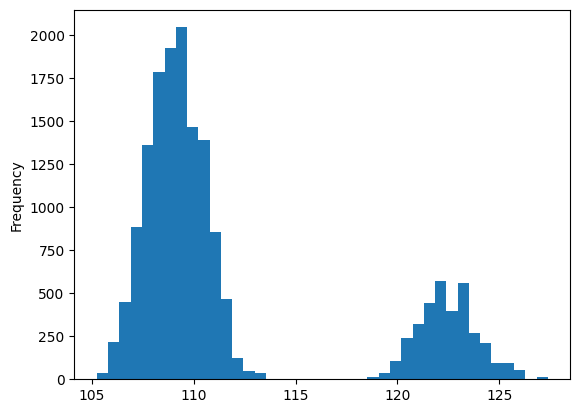

In [10]:
df_secs[df_secs['last_section_name'] == 'sec5']['sec5'].plot(kind='hist', bins=40)

Hier gibt es zwei Normalverteilunge, vermutlich, weil sich trotz langer Sections die Rennstrecke nochmal unterscheidet.
Lasst uns das kurz überprüfen:

In [11]:
df_secs[df_secs['last_section_name'] == 'sec5'].groupby('info_distance')['sec5'].mean()

info_distance
1800    109.110067
2000    122.495883
Name: sec5, dtype: float64

Das scheint die korrekte Erklärung zu sein.

Als wollen wir einen einheitlichen Wert bauen, der aussagt, wie schnell oder langsam das Rennen im Vergleich zum Durchschnitt ist.

In [12]:
secs = list(df_secs['last_section_name'].unique())

for sec in secs:
    lengths = list(df_secs[df_secs['last_section_name'] == sec]['info_distance'].unique())
    for length in lengths:
        mask = (df_secs['last_section_name'] == sec) & (df_secs['info_distance'] == length)
        sec_mean = df_secs.loc[mask, sec].mean()
        df_secs.loc[mask, 'speed_normalized'] = df_secs.loc[mask, sec] / sec_mean

In [13]:
df_secs.head()

,sec1,sec2,sec3,sec4,sec5,sec6,last_section_name,info_distance,speed_normalized
0,24.31,47.78,72.34,95.78,NaN,NaN,sec4,1600,1.005778
1,24.31,47.78,72.34,95.78,NaN,NaN,sec4,1600,1.005778
2,24.31,47.78,72.34,95.78,NaN,NaN,sec4,1600,1.005778
3,24.31,47.78,72.34,95.78,NaN,NaN,sec4,1600,1.005778
4,24.31,47.78,72.34,95.78,NaN,NaN,sec4,1600,1.005778


<Axes: ylabel='Frequency'>

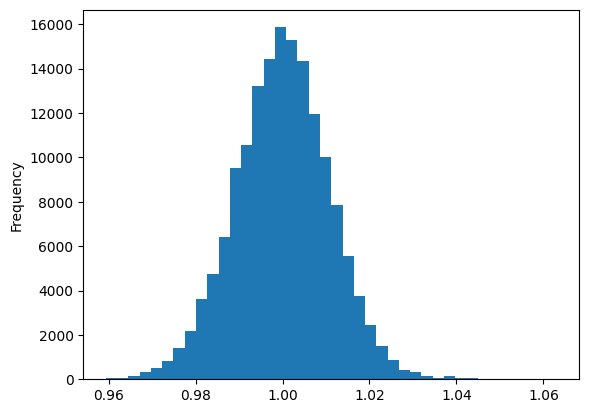

In [14]:
df_secs['speed_normalized'].plot(kind='hist', bins=40)

Das sieht besser aus. Nun fügen wir diese Spalte wieder an unseren ursprünglichen Dataframe an, und löschen die sec-Spalten.

In [15]:
df['speed_normalized'] = df_secs['speed_normalized']
df = df.drop(columns=['sec1', 'sec2', 'sec3', 'sec4', 'sec5', 'sec6'])

In [16]:
df.columns

Index(['date', 'location', 'race_no', 'info', 'going', 'course', 'place',
       'horse_number', 'horse_name', 'jockey', 'trainer', 'weight',
       'on_date_horse_weight', 'draw', 'length_behind_winner',
       'running_position', 'finish_time', 'win_odds', 'race_id_number',
       'race_id_year', 'info_class', 'info_distance', 'info_rating',
       'surface_type', 'rail_offset', 'place_numeric', 'finish_time_seconds',
       'speed_normalized'],
      dtype='str')

In [17]:
df['speed_normalized'].corr(df['finish_time_seconds'])

np.float64(0.04718351193622115)

In [18]:
df.head()

,date,location,race_no,info,going,course,place,horse_number,horse_name,jockey,...,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized
0,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",1,1.0,BEAUTIFUL CHOICE(CH130),K C Leung,...,1,264,Class 4,1600,60-40,TURF,2,1.0,95.78,1.005778
1,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",2,9.0,LIVERBIRD(CE055),H W Lai,...,1,264,Class 4,1600,60-40,TURF,2,2.0,95.81,1.005778
2,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",3,10.0,GREEN GLORY(CJ177),W C Marwing,...,1,264,Class 4,1600,60-40,TURF,2,3.0,96.04,1.005778
3,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",4,4.0,BRILLIANT FLASH(CE042),O Doleuze,...,1,264,Class 4,1600,60-40,TURF,2,4.0,96.07,1.005778
4,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",5,2.0,DR WELL(CD165),M L Yeung,...,1,264,Class 4,1600,60-40,TURF,2,5.0,96.41,1.005778


Nun kümmern wir uns um finish_time_seconds. Dieses feature beschreibt die Finish time des einzelnen Pferdes. Auch dieses Feature wollen wir normalisieren, ein mal im Vergleich zu den 

Pferden im jeweiligen Rennen, und einmal im Vergleich zu allen vergleichbaren Rennen. 

Erstmal müssen wir herausfinden, was vergleichbare Rennen sind.

Dazu müssen wir folgende Fragen klären:

1. Unterscheiden sich die Rennen in Sha Tin und Happy Valley?
2. Hat das Going einen Einfluss auf die Performance?
3. Hat die Startnummer einen Einfluss auf die Performance?
4. Hat die Class einen Einfluss auf die Performance?

In [19]:
def feature_check(feature1, feature2):
    df_fc = pd.DataFrame({
        'distance' : sorted([int(x) for x in df['info_distance'].unique()])
    })

    for feature_1 in list(df[feature1].unique()):
        for feature_2 in list(df[feature2].unique()):
            mask = (df[feature2] == feature_2) & (df[feature1] == feature_1)
            group_mean = df.loc[mask, 'finish_time_seconds'].mean()
            df_fc.loc[df_fc['distance'] == feature_2, feature_1] = group_mean
    return df_fc

### 1. Unterscheiden sich die Rennen in Sha Tin und Happy Valley?

In [20]:
feature_check('location', 'info_distance').head(10)


,distance,Sha Tin,Happy Valley
0,1000,57.518183,57.868839
1,1200,70.272002,70.747654
2,1400,83.186881,NaN
3,1600,96.037152,NaN
4,1650,100.304782,101.314275
5,1800,109.351646,110.789456
6,2000,123.387112,NaN
7,2200,136.795125,138.457124
8,2400,148.899313,NaN


Während es teilweise bestimmte Rennen nur bei einem der beiden Standorte gibt (1400, 1600, ...), ist auffällig, dass der Durchschnitt im Happy Valley immer leicht höher ist als in Sha Tin. Warum das so ist, lässt sich nicht direkt erklären. Ein Grund könnte die Uhrzeit sein, da die Rennen im Happy Valley normalerweise erst Abends bis spät in die Nacht stattfinden, während sie in Sha Tin schon um 12 Uhr mittags beginnen, während die Pferde noch 'frischer' sind.

Wir beschließen, dass der Aufwand, die beiden Strecken nachher zu unterscheiden, gering genug ist, um diesen Unterschied in unser End-Feature mit aufzunehmen.

### 2. Hat das Going einen Einfluss auf die Performance?

In [21]:
feature_check('going', 'info_distance').head(10)

,distance,GOOD TO FIRM,FAST,GOOD,GOOD TO YIELDING,YIELDING,SOFT,WET SLOW,YIELDING TO SOFT,SLOW,WET FAST,HEAVY,SEALED
0,1000,57.384094,NaN,57.747309,58.202656,58.373315,57.951200,NaN,NaN,NaN,NaN,NaN,NaN
1,1200,70.248073,69.785886,70.489790,71.264824,71.628240,72.247459,70.673103,72.841774,70.628750,69.834868,71.090000,NaN
2,1400,82.852339,NaN,83.213236,84.092933,84.855818,86.226923,NaN,85.050370,NaN,NaN,NaN,NaN
3,1600,95.632192,NaN,96.070226,97.324340,97.334815,98.291463,NaN,98.288889,NaN,NaN,97.950714,NaN
4,1650,100.798210,100.228415,101.080907,102.072706,103.103317,105.355000,100.993337,106.308333,102.533500,100.800159,NaN,101.067143
5,1800,109.398182,108.931984,110.031688,110.919471,112.016263,109.622500,111.217616,NaN,110.411852,109.224857,NaN,NaN
6,2000,122.777227,NaN,123.498403,124.759044,123.825088,126.070833,NaN,124.683333,NaN,NaN,NaN,NaN
7,2200,137.362429,NaN,138.462851,140.054286,140.795500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2400,148.485618,NaN,148.636895,149.745937,152.903333,152.397500,NaN,NaN,NaN,NaN,NaN,NaN


Hier zu sehen: Die Unterschiede zwischen den Durchschnitts-Rennzeiten sind hier teilweise sogar im Sekunden-Bereich. Das lässt darauf schließen, dass das 'going', also der Untergrund, einen Einfluss auf die Performance des Pferdes hat. Demnach beziehen wir auch das in unser Feature mit ein.

Ebenfalls interessant: Während es 'Good' und 'Good To Yielding' auf fast allen Rennstrecken gelaufen werden, gibt es Untergründe, die nur auf bestimmten Rennstrecken gelaufen werden.

### 3. Hat die Startnummer einen Einfluss auf die Performance?

In [22]:
feature_check('draw', 'info_distance').head(10)

,distance,4.0,8.0,2.0,9.0,6.0,1.0,7.0,10.0,3.0,5.0,13.0,14.0,12.0,11.0,NaN,15.0
0,1000,57.682821,57.697369,57.673737,57.711806,57.686742,57.696893,57.653651,57.695004,57.672050,57.659646,57.495690,57.497689,57.762247,57.750160,NaN,58.47
1,1200,70.409892,70.481739,70.361997,70.523372,70.463072,70.331327,70.468976,70.552666,70.394901,70.410396,70.596763,70.668508,70.627318,70.604979,NaN,NaN
2,1400,83.116291,83.205422,83.112535,83.212505,83.120923,83.057211,83.148919,83.237938,83.082250,83.104011,83.312632,83.379109,83.312831,83.291519,NaN,NaN
3,1600,95.944865,96.020048,95.938884,96.058045,95.993128,95.907804,95.998679,96.108787,95.980910,95.948319,96.235149,96.297245,96.158638,96.123398,NaN,NaN
4,1650,101.019564,101.162687,100.940876,101.216820,101.058299,100.869808,101.090149,101.167932,100.965311,101.002458,100.605909,100.601075,101.261082,101.220967,NaN,NaN
5,1800,109.904657,110.026021,109.857286,110.027598,109.920239,109.845367,109.984092,110.052213,109.925752,109.866641,109.530858,109.682841,110.230908,110.139989,NaN,NaN
6,2000,123.193429,123.345055,123.223488,123.337761,123.257936,123.149184,123.344337,123.756128,123.072730,123.303369,123.995734,123.927522,123.712753,123.669048,NaN,NaN
7,2200,138.203892,138.267640,138.034545,138.404000,138.175882,138.017112,138.441351,138.309684,138.094409,138.247540,137.854000,137.221250,138.709009,138.643704,NaN,NaN
8,2400,148.741957,148.484211,148.888913,149.109655,149.098810,149.101957,148.378250,149.244000,149.211778,148.741957,149.563000,147.815000,148.679333,149.220000,NaN,NaN


In [23]:
for distance in list(df['info_distance'].unique()):
    mask = df['info_distance'] == distance

    corr = df.loc[mask]['draw'].corr(df.loc[mask]['finish_time_seconds'])
    print(f"{distance}: {corr}")

1600: 0.07450594415192975
1400: 0.06496618318395853
1200: 0.07899801230571202
1000: -0.0035379279808371734
1800: 0.027541374894932098
1650: 0.058606309004885254
2000: 0.13157312369056923
2200: 0.08567804148764123
2400: -0.012756112935464274


Die Korrelation ist gering, aber um sauber zu arbeiten, nehmen wir sie mit auf.

### 4. Hat die Class einen Einfluss auf die Performance?

In [24]:
feature_check('info_class', 'info_distance').head(10)

,distance,Class 4,Class 5,Class 3,Class 2,Hong Kong Group Three,Class 1,Class 4 (Special Condition),Hong Kong Group One,Class 4 (Bonus Prize Money),...,Griffin Race,Hong Kong Group Two,Restricted Race,Class 3 (Special Condition),Group One,Group Two,Class 4 (Restricted),Group Three,4 Year Olds,Class 3 (Restricted)
0,1000,57.865200,58.183876,57.483261,57.064326,56.734242,56.799214,NaN,56.856575,NaN,...,57.969596,NaN,NaN,NaN,NaN,NaN,58.032805,56.507692,NaN,NaN
1,1200,70.695417,70.915077,70.284915,69.773075,69.483958,69.633128,71.060590,69.581412,71.700357,...,71.077017,69.499280,71.345185,70.891750,69.309755,68.882952,70.692976,68.935122,NaN,NaN
2,1400,83.413616,83.800308,82.955906,82.611509,82.156845,82.397257,83.916786,82.038077,84.432500,...,84.802075,NaN,83.381875,82.146429,81.860103,NaN,83.785327,81.759244,NaN,NaN
3,1600,96.414597,96.875841,95.965233,95.572546,94.640256,95.205844,NaN,95.375511,96.533077,...,NaN,94.908189,96.549000,NaN,94.613165,94.252077,NaN,94.287662,94.844639,95.129762
4,1650,101.240335,101.651357,100.746076,100.072571,NaN,100.012271,101.722279,NaN,NaN,...,NaN,NaN,NaN,102.467941,NaN,NaN,NaN,NaN,NaN,NaN
5,1800,110.193141,110.898567,109.641991,109.183096,108.595361,109.250365,NaN,109.269079,110.636667,...,NaN,109.375926,108.253846,NaN,NaN,NaN,NaN,108.057104,107.544340,NaN
6,2000,124.223746,124.612544,123.160443,122.700404,NaN,123.073016,NaN,123.274103,NaN,...,NaN,124.627143,123.992857,NaN,122.281963,121.671111,NaN,NaN,121.895268,NaN
7,2200,138.376441,138.986048,137.505973,135.990000,NaN,137.566667,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2400,NaN,NaN,NaN,NaN,150.723506,NaN,NaN,148.896250,NaN,...,NaN,NaN,NaN,NaN,148.275038,NaN,NaN,149.189250,NaN,NaN


1. Unterscheiden sich die Rennen in Sha Tin und Happy Valley? ✅
2. Hat das Going einen Einfluss auf die Performance? ✅
3. Hat die Startnummer einen Einfluss auf die Performance? ✅
4. Hat die Class einen Einfluss auf die Performance? ✅

In [25]:
df['info_class'].unique()

<ArrowStringArray>
[                    'Class 4',                     'Class 5',
                     'Class 3',                     'Class 2',
       'Hong Kong Group Three',                     'Class 1',
 'Class 4 (Special Condition)',         'Hong Kong Group One',
 'Class 4 (Bonus Prize Money)', 'Class 2 (Bonus Prize Money)',
 'Class 3 (Bonus Prize Money)',                'Griffin Race',
         'Hong Kong Group Two',             'Restricted Race',
 'Class 3 (Special Condition)',                   'Group One',
                   'Group Two',        'Class 4 (Restricted)',
                 'Group Three',                 '4 Year Olds',
        'Class 3 (Restricted)']
Length: 21, dtype: str

## Performance within the Race

Now we create a feature where we bring the finish time in relation to the other horses' finish time within the same race. To do that, we calculate the z-score for each observation.

We differentiate between these variables:

1. Distance
2. Location
3. Going
4. Draw

First, it make sense to definde a unique race identifier.

In [26]:
i = 1
for date in list(df['date'].unique()):
    date_val = df['date'] == date
    for race in list(df.loc[date_val, 'race_no'].unique()):
        mask = (df['date'] == date) & (df['race_no'] == race)
        df.loc[mask, 'unique_id'] = i
        i += 1

In [27]:
len(list(df['unique_id'].unique()))

12634

In [28]:
df.head(15)

,date,location,race_no,info,going,course,place,horse_number,horse_name,jockey,...,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized,unique_id
0,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",1,1.0,BEAUTIFUL CHOICE(CH130),K C Leung,...,264,Class 4,1600,60-40,TURF,2,1.0,95.78,1.005778,1.0
1,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",2,9.0,LIVERBIRD(CE055),H W Lai,...,264,Class 4,1600,60-40,TURF,2,2.0,95.81,1.005778,1.0
2,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",3,10.0,GREEN GLORY(CJ177),W C Marwing,...,264,Class 4,1600,60-40,TURF,2,3.0,96.04,1.005778,1.0
3,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",4,4.0,BRILLIANT FLASH(CE042),O Doleuze,...,264,Class 4,1600,60-40,TURF,2,4.0,96.07,1.005778,1.0
4,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",5,2.0,DR WELL(CD165),M L Yeung,...,264,Class 4,1600,60-40,TURF,2,5.0,96.41,1.005778,1.0
5,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",6,6.0,FORTUNE WARRIOR(CD096),B Doyle,...,264,Class 4,1600,60-40,TURF,2,6.0,96.57,1.005778,1.0
6,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",7,8.0,RAIN OF THUNDER(CJ352),D Whyte,...,264,Class 4,1600,60-40,TURF,2,7.0,96.69,1.005778,1.0
7,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",8,7.0,FAST GO(CJ181),P H Lo,...,264,Class 4,1600,60-40,TURF,2,8.0,97.27,1.005778,1.0
8,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",9,3.0,VERY FIT(CE071),J Victoire,...,264,Class 4,1600,60-40,TURF,2,9.0,97.39,1.005778,1.0
9,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",10,5.0,SCOOT DA LOOT(CH274),Y T Cheng,...,264,Class 4,1600,60-40,TURF,2,10.0,97.44,1.005778,1.0


Calculating a robust MAD for each horse in each specific race. 
The individual horse performance during a race can be compared to every race, no matter the track or length.

In [29]:
df['performance_within_race'] = None

for race in df['unique_id'].unique():
    mask = df['unique_id'] == race
    times = df.loc[mask, 'finish_time_seconds'].dropna()
    median = times.median()
    mad = np.median(np.abs(times - median))

    if mad == 0:
        df.loc[mask, 'performance_within_race'] = 0  # alle gleich
    else:
        df.loc[mask, 'performance_within_race'] = 0.6745 * (times - median) / mad
"""
    if np.isnan(iqr_val)
        df.loc[mask, 'performance_within_race'] = np.nan
    else:
        df.loc[mask, 'performance_within_race'] = (times - median) / iqr_val

        """

"\n    if np.isnan(iqr_val)\n        df.loc[mask, 'performance_within_race'] = np.nan\n    else:\n        df.loc[mask, 'performance_within_race'] = (times - median) / iqr_val\n\n        "

In [30]:
for race in df['unique_id'].unique():
    mask = df['unique_id'] == race
    times = pd.to_numeric(df.loc[mask, 'finish_time_seconds'], errors='coerce')
    med = times.median()
    mad = times.sub(med).abs().median()
    mad = max(mad, 0.1, abs(med) * 0.002)  # Mindest-MAD: 0.1s oder 0.2% vom Median
    df.loc[mask, 'performance_within_race'] = (0.6745 * (times - med) / mad).clip(-8, 8)

In [31]:
df['place_numeric'].corr(df['performance_within_race'])

np.float64(0.8007215609333275)

<Axes: xlabel='performance_within_race', ylabel='Count'>

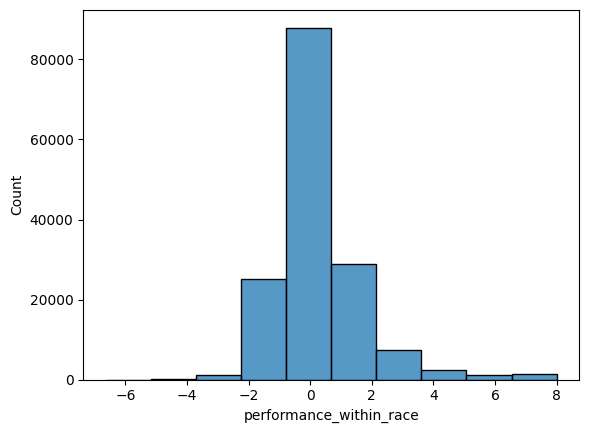

In [32]:
sns.histplot(data=df, x='performance_within_race', bins=10)

Next, we create a score for each individual racing performance within the given circumstances (means all the races with same length, locatiom, going, etc.) are compared.
First we look at the amount of single groups, so groups that have such unique features that there are less than 5 observations.

In [33]:
# 1. Gruppengrößen berechnen
group_sizes = (
    df.groupby(['info_distance', 'location', 'going', 'draw'])
      .size()
      .reset_index(name='count')
)

# 2. Gruppen unter 5 Einträgen
small_groups = group_sizes[group_sizes['count'] < 5]

# 3. Kennzahlen
total_groups = len(group_sizes)
small_groups_count = len(small_groups)
percent_small_groups = small_groups_count / total_groups * 100

# 4. Anteil der Pferde/Rennen, die wegfallen würden
rows_in_small_groups = df.merge(small_groups, on=['info_distance','location','going','draw']).shape[0]
total_rows = len(df)
percent_rows_lost = rows_in_small_groups / total_rows * 100

print(f"Total Amount of Groups: {total_groups}")
print(f"Small Groups (<5): {small_groups_count} ({percent_small_groups:.1f} %)")
print(f"Amount of Observations in Small Groups: {rows_in_small_groups} ({percent_rows_lost:.1f} % der Daten)")

Total Amount of Groups: 1059
Small Groups (<5): 289 (27.3 %)
Amount of Observations in Small Groups: 493 (0.3 % der Daten)


Here we can see that only 0.4% of our observations belong to such small groups. They truly are bordercombinations and have no statistical significance. Therefore we can fill them with "NaN".

In [34]:
df['performance_within_conditions'] = np.nan

for distance in df['info_distance'].dropna().unique():
    for location in df['location'].dropna().unique():
        for going in df['going'].dropna().unique():
            for draw in df['draw'].dropna().unique():
                mask = (
                    (df['info_distance'] == distance) &
                    (df['location'] == location) &
                    (df['going'] == going) &
                    (df['draw'] == draw)
                )

                # If group is small -> set NaN
                if (distance, location, going, draw) in small_groups.set_index(['info_distance','location','going','draw']).index:
                    df.loc[mask, 'performance_within_conditions'] = np.nan
                    continue

                times = pd.to_numeric(df.loc[mask, 'finish_time_seconds'], errors='coerce').dropna()
                med = times.median()
                mad = (times - med).abs().median()
                denom = max(mad, 0.1, abs(med) * 0.002)
                score = 0.6745 * (df.loc[mask, 'finish_time_seconds'] - med) / denom
                df.loc[mask, 'performance_within_conditions'] = score.clip(-8, 8)




<Axes: xlabel='performance_within_conditions', ylabel='Count'>

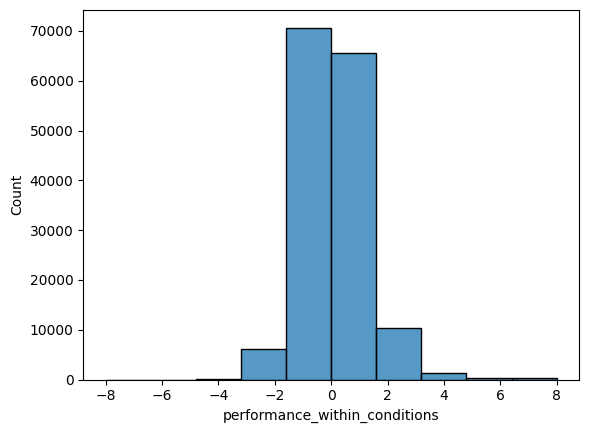

In [35]:
sns.histplot(data=df, x='performance_within_conditions', bins=10)

In [36]:
features = ['place_numeric', 'performance_within_conditions', 'performance_within_race']

In [37]:
df[features].corr()

,place_numeric,performance_within_conditions,performance_within_race
place_numeric,1.000000,0.549264,0.800722
performance_within_conditions,0.549264,1.000000,0.628335
performance_within_race,0.800722,0.628335,1.000000


Now we create an additional target variable called "top3".
This one is simple: If the horse is in the Top 3, the value is "Yes", otherwise it's "No"

In [38]:
df['top3'] = (df['place_numeric'] <= 3).map({True: "Yes", False: "No"})

In [39]:
df.iloc[1000:10020,:]

,date,location,race_no,info,going,course,place,horse_number,horse_name,jockey,...,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized,unique_id,performance_within_race,performance_within_conditions,top3
1000,2009-01-28 00:00:00+08:00,Sha Tin,RACE 4 (342),Class 4 (Bonus Prize Money) - 1200M - (60-40),GOOD,"TURF - ""B+2"" Course",1,2.0,PACHINKO(CH208),W C Marwing,...,60-40,TURF,2,1.0,70.62,1.013018,79.0,-0.715379,0.537314,Yes
1001,2009-01-28 00:00:00+08:00,Sha Tin,RACE 4 (342),Class 4 (Bonus Prize Money) - 1200M - (60-40),GOOD,"TURF - ""B+2"" Course",2,11.0,WONDERFUL GAINS(CK050),D Whyte,...,60-40,TURF,2,2.0,70.62,1.013018,79.0,-0.715379,0.558207,Yes
1002,2009-01-28 00:00:00+08:00,Sha Tin,RACE 4 (342),Class 4 (Bonus Prize Money) - 1200M - (60-40),GOOD,"TURF - ""B+2"" Course",3,13.0,STAY YOUNG(CD109),K C Leung,...,60-40,TURF,2,3.0,70.68,1.013018,79.0,-0.633621,0.662871,Yes
1003,2009-01-28 00:00:00+08:00,Sha Tin,RACE 4 (342),Class 4 (Bonus Prize Money) - 1200M - (60-40),GOOD,"TURF - ""B+2"" Course",4,5.0,SOU MA TAM(CH253),J Victoire,...,60-40,TURF,2,4.0,70.77,1.013018,79.0,-0.510985,0.720229,No
1004,2009-01-28 00:00:00+08:00,Sha Tin,RACE 4 (342),Class 4 (Bonus Prize Money) - 1200M - (60-40),GOOD,"TURF - ""B+2"" Course",5,1.0,TRUE INTELLIGENCE(CK060),O Doleuze,...,60-40,TURF,2,5.0,70.78,1.013018,79.0,-0.497359,0.786917,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10015,2010-01-16 00:00:00+08:00,Sha Tin,RACE 8 (319),Class 3 - 1600M - (80-60),GOOD,"TURF - ""C+3"" Course",13,7.0,ROYAL PEGASUS(CK103),K L Chui,...,80-60,TURF,3,13.0,96.99,0.996537,781.0,0.922168,0.712500,No
10016,2010-01-16 00:00:00+08:00,Sha Tin,RACE 8 (319),Class 3 - 1600M - (80-60),GOOD,"TURF - ""C+3"" Course",14,6.0,MY GOAL(CJ131),Y T Cheng,...,80-60,TURF,3,14.0,97.79,0.996537,781.0,1.765293,1.529500,No
10017,2010-01-16 00:00:00+08:00,Sha Tin,RACE 9 (320),Class 2 - 1800M - (95-75),GOOD,"TURF - ""C+3"" Course",1,5.0,SUPER SATIN(CK116),D Whyte,...,95-75,TURF,3,1.0,107.93,0.989185,782.0,-1.242899,-1.096062,Yes
10018,2010-01-16 00:00:00+08:00,Sha Tin,RACE 9 (320),Class 2 - 1800M - (95-75),GOOD,"TURF - ""C+3"" Course",2,2.0,BEAUTY FOREVER(CK074),M Chadwick,...,95-75,TURF,3,2.0,108.10,0.989185,782.0,-0.985225,-0.949296,Yes


In [40]:
features = ['place_numeric', 'jockey', 'horse_name']

In [41]:
df['jockey'].value_counts()

jockey
Z Purton      9749
K C Leung     8100
K Teetan      7742
M Chadwick    7524
C Y Ho        7071
              ... 
A Sugawara       1
R Ryan           1
E Baird          1
O Orr            1
K Stott          1
Name: count, Length: 249, dtype: int64

In [42]:
len(df['jockey'].unique())

249

In [43]:
len(df['horse_name'].unique())

8493

In [44]:
# Maximalanzahl an Zeilen und Spalten für die Anzeige setzen
pd.set_option('display.max_rows', None)  # Alle Zeilen anzeigen
pd.set_option('display.max_columns', None)  # Alle Spalten anzeigen
pd.set_option('display.width', None)  # Zeilen nicht umbrechen
pd.set_option('display.max_colwidth', None)  # Ganze Spalteninhalte anzeigen

# Beispiel
df.head()

,date,location,race_no,info,going,course,place,horse_number,horse_name,jockey,trainer,weight,on_date_horse_weight,draw,length_behind_winner,running_position,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized,unique_id,performance_within_race,performance_within_conditions,top3
0,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",1,1.0,BEAUTIFUL CHOICE(CH130),K C Leung,Y S Tsui,119,1114.0,4.0,0.00,3321,1:35.78,5.6,1,264,Class 4,1600,60-40,TURF,2,1.0,95.78,1.005778,1.0,-0.847602,0.291676,Yes
1,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",2,9.0,LIVERBIRD(CE055),H W Lai,C S Shum,118,1125.0,8.0,0.20,6652,1:35.81,15.0,1,264,Class 4,1600,60-40,TURF,2,2.0,95.81,1.005778,1.0,-0.811788,0.197415,Yes
2,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",3,10.0,GREEN GLORY(CJ177),W C Marwing,P F Yiu,118,1063.0,2.0,1.50,5563,1:36.04,3.6,1,264,Class 4,1600,60-40,TURF,2,3.0,96.04,1.005778,1.0,-0.537212,0.474648,Yes
3,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",4,4.0,BRILLIANT FLASH(CE042),O Doleuze,C Fownes,127,1144.0,9.0,1.75,101074,1:36.07,8.4,1,264,Class 4,1600,60-40,TURF,2,4.0,96.07,1.005778,1.0,-0.501398,0.296122,No
4,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",5,2.0,DR WELL(CD165),M L Yeung,C W Chang,118,1122.0,6.0,4.00,2235,1:36.41,9.5,1,264,Class 4,1600,60-40,TURF,2,5.0,96.41,1.005778,1.0,-0.095504,0.762097,No


In [45]:
horses_few_races = df['horse_name'].value_counts()
horses_few_races = horses_few_races[horses_few_races < 5]

print(horses_few_races)

horse_name
NEW ASIA FORWARD(CH309)      4
ME THE BEST(CJ158)           4
MEGA HILL(CJ336)             4
WARRIOR(CH066)               4
HIT SONG(CJ232)              4
NOBLE HEART(CC355)           4
NEVER LOOK BACK(CJ043)       4
DOUBLE FANTASY(CG141)        4
KEEN TAKER(CH022)            4
LONDON EXPRESS(CH107)        4
ELFHELM(CC342)               4
SUPER SNIPPETS(CG217)        4
O'REILLY RALLY(CH266)        4
SEA TREASURE(CD335)          4
POS TRUMPS(CH295)            4
PLEASURE PLEASURE(CD271)     4
THREE CLUBS(CG149)           4
CHAMPION PIONEER(CG305)      4
WONDERFUL BLESSING(CE198)    4
REDHILL COMMANDER(CH078)     4
PUERTO RICO(CH147)           4
GALAXY DANCER(CH179)         4
TCHAIKOVSKY(CE030)           4
CHIRAC(CJ234)                4
DIAMOND FLYER(CG199)         4
SPEEDY GROWTH(CJ249)         4
CALIFORNIAMOUNTAIN(CG310)    4
HAIL THE STORM(CE125)        4
HAWKES BAY(CG064)            4
FOREVER RICHES(CG174)        4
BAAZIGAR(CG171)              4
GOSHAWK(CK144)              

In [46]:
len(horses_few_races)

1641

<Axes: xlabel='count', ylabel='Count'>

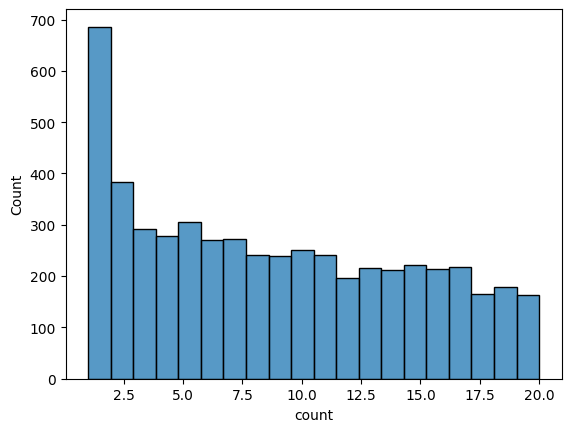

In [47]:
cutoff = 20

horses_few_races = df['horse_name'].value_counts()
horses_few_races = horses_few_races[horses_few_races <= cutoff]

sns.histplot(data=df, x=horses_few_races, bins=cutoff)

In [48]:
jockey_few_races = df['jockey'].value_counts()
cutoff = 25
jockey_few_races = jockey_few_races[jockey_few_races <= cutoff]

print(len(jockey_few_races))

133


<Axes: xlabel='count', ylabel='Count'>

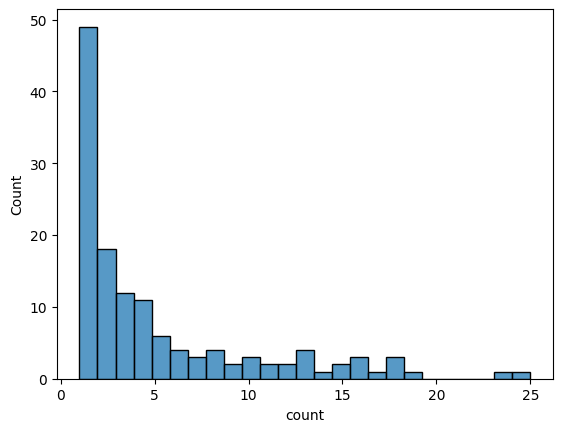

In [49]:
sns.histplot(data=df, x=jockey_few_races, bins=cutoff)

In [50]:
df.tail(10)

,date,location,race_no,info,going,course,place,horse_number,horse_name,jockey,trainer,weight,on_date_horse_weight,draw,length_behind_winner,running_position,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized,unique_id,performance_within_race,performance_within_conditions,top3
158553,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",5,1.0,SUPERB KID(H298),L Ferraris,K W Lui,135,1037.0,12.0,3.00,1413125,1:21.59,21.0,11,838,Class 3,1400,80-60,TURF,0,5.0,81.59,0.984984,12634.0,-0.152887,-1.236583,No
158554,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",6,13.0,SOLID CAR(K058),M F Poon,D J Hall,118,1083.0,9.0,3.00,111086,1:21.60,44.0,11,838,Class 3,1400,80-60,TURF,0,6.0,81.60,0.984984,12634.0,-0.1349,-1.227936,No
158555,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",7,4.0,SOUTH STAR(K153),A Atzeni,F C Lor,125,1007.0,3.0,3.50,4447,1:21.65,3.1,11,838,Class 3,1400,80-60,TURF,0,7.0,81.65,0.984984,12634.0,-0.044967,-1.081341,No
158556,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",8,8.0,SKY VINO(K054),E C W Wong,C Fownes,117,1095.0,14.0,3.75,1314138,1:21.70,13.0,11,838,Class 3,1400,80-60,TURF,0,8.0,81.70,0.984984,12634.0,0.044967,-1.281027,No
158557,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",9,3.0,RISING FROM ASHES(G209),A Hamelin,C W Chang,126,1009.0,13.0,4.00,8899,1:21.76,21.0,11,838,Class 3,1400,80-60,TURF,0,9.0,81.76,0.984984,12634.0,0.152887,-1.137590,No
158558,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",10,7.0,FLASH CURRENT(J500),H Bentley,K H Ting,123,1047.0,1.0,5.25,77710,1:21.96,13.0,11,838,Class 3,1400,80-60,TURF,0,10.0,81.96,0.984984,12634.0,0.51262,-0.708797,No
158559,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",11,9.0,STELLAR SWIFT(J139),B Thompson,D A Hayes,122,1188.0,8.0,6.75,1291111,1:22.20,22.0,11,838,Class 3,1400,80-60,TURF,0,11.0,82.20,0.984984,12634.0,0.9443,-0.552786,No
158560,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",12,2.0,GHORGAN(K199),K C Leung,K L Man,131,1107.0,11.0,7.00,51312,1:22.24,43.0,11,838,Class 3,1400,80-60,TURF,0,12.0,82.24,0.984984,12634.0,1.016247,-0.601862,No
158561,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",13,6.0,CALIFORNIA WAVES(K477),Y L Chung,W K Mo,122,1104.0,2.0,9.25,9111413,1:22.58,105.0,11,838,Class 3,1400,80-60,TURF,0,13.0,82.58,0.984984,12634.0,1.627793,-0.055287,No
158562,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",14,11.0,MASTER CHAMPION(K266),H T Mo,C S Shum,117,1218.0,6.0,20.75,25614,1:24.44,111.0,11,838,Class 3,1400,80-60,TURF,0,14.0,84.44,0.984984,12634.0,4.973313,1.632486,No


In [51]:
df['win'] = (df['place_numeric'] == 1).map({True: 1, False: 0})

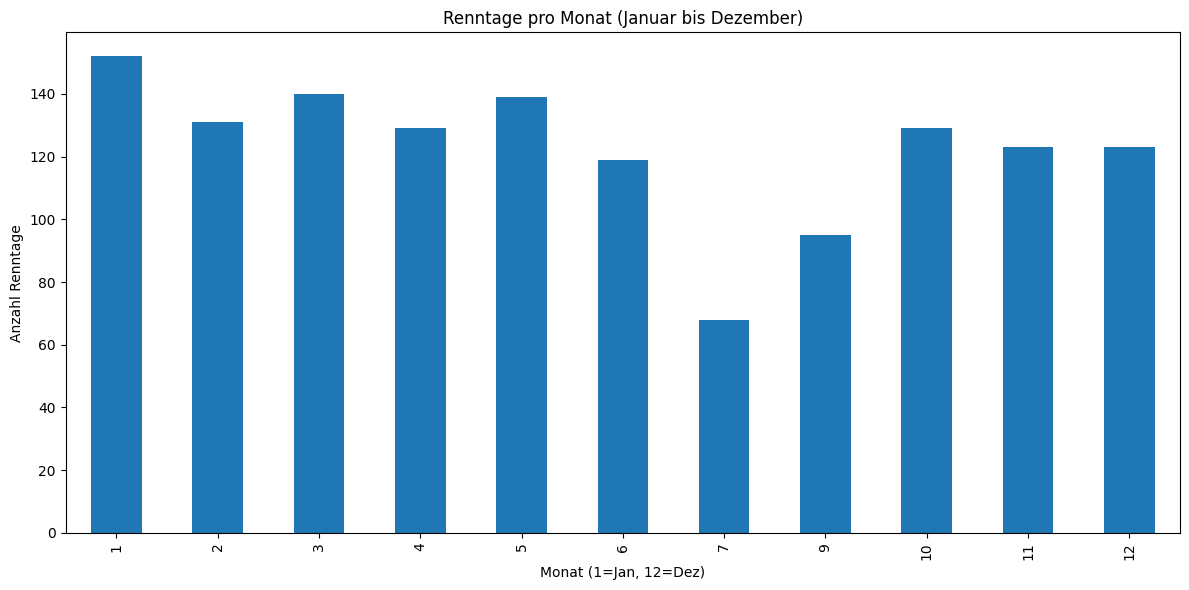

In [52]:
unique_dates = pd.to_datetime(df['date']).dropna().unique()
months_only = unique_dates.month

# Histogramm: Anzahl der Renntage pro Monat (über alle Jahre)
plt.figure(figsize=(12, 6))
pd.Series(months_only).value_counts().sort_index().plot(kind='bar')
plt.xlabel('Monat (1=Jan, 12=Dez)')
plt.ylabel('Anzahl Renntage')
plt.title('Renntage pro Monat (Januar bis Dezember)')
plt.tight_layout()
plt.show()


We observe that in August are no races. This means there is a seasonal break between July and September. According to internet research, the season ends around July 17th and starts again around August 31st.

To create good performance features, we want to differentiate the performance between the seasons. To do that, we first need to build a feature that contains the correct season.

In [53]:
df['date'] = pd.to_datetime(df['date'])

In [54]:
season = 1
seasons = []

for i in range(len(df)):
    current_date = df['date'].iloc[i]
    if i == 0:
        seasons.append(season)
        continue
    prev_date = df['date'].iloc[i-1]
    if current_date.month == 9 and prev_date.month != 9:
        season += 1
    seasons.append(season)

In [55]:
df['season'] = seasons

In [56]:
df.head()

,date,location,race_no,info,going,course,place,horse_number,horse_name,jockey,trainer,weight,on_date_horse_weight,draw,length_behind_winner,running_position,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized,unique_id,performance_within_race,performance_within_conditions,top3,win,season
0,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",1,1.0,BEAUTIFUL CHOICE(CH130),K C Leung,Y S Tsui,119,1114.0,4.0,0.00,3321,1:35.78,5.6,1,264,Class 4,1600,60-40,TURF,2,1.0,95.78,1.005778,1.0,-0.847602,0.291676,Yes,1,1
1,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",2,9.0,LIVERBIRD(CE055),H W Lai,C S Shum,118,1125.0,8.0,0.20,6652,1:35.81,15.0,1,264,Class 4,1600,60-40,TURF,2,2.0,95.81,1.005778,1.0,-0.811788,0.197415,Yes,0,1
2,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",3,10.0,GREEN GLORY(CJ177),W C Marwing,P F Yiu,118,1063.0,2.0,1.50,5563,1:36.04,3.6,1,264,Class 4,1600,60-40,TURF,2,3.0,96.04,1.005778,1.0,-0.537212,0.474648,Yes,0,1
3,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",4,4.0,BRILLIANT FLASH(CE042),O Doleuze,C Fownes,127,1144.0,9.0,1.75,101074,1:36.07,8.4,1,264,Class 4,1600,60-40,TURF,2,4.0,96.07,1.005778,1.0,-0.501398,0.296122,No,0,1
4,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",5,2.0,DR WELL(CD165),M L Yeung,C W Chang,118,1122.0,6.0,4.00,2235,1:36.41,9.5,1,264,Class 4,1600,60-40,TURF,2,5.0,96.41,1.005778,1.0,-0.095504,0.762097,No,0,1


In [57]:
df.tail(10)

,date,location,race_no,info,going,course,place,horse_number,horse_name,jockey,trainer,weight,on_date_horse_weight,draw,length_behind_winner,running_position,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized,unique_id,performance_within_race,performance_within_conditions,top3,win,season
158553,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",5,1.0,SUPERB KID(H298),L Ferraris,K W Lui,135,1037.0,12.0,3.00,1413125,1:21.59,21.0,11,838,Class 3,1400,80-60,TURF,0,5.0,81.59,0.984984,12634.0,-0.152887,-1.236583,No,0,16
158554,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",6,13.0,SOLID CAR(K058),M F Poon,D J Hall,118,1083.0,9.0,3.00,111086,1:21.60,44.0,11,838,Class 3,1400,80-60,TURF,0,6.0,81.60,0.984984,12634.0,-0.1349,-1.227936,No,0,16
158555,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",7,4.0,SOUTH STAR(K153),A Atzeni,F C Lor,125,1007.0,3.0,3.50,4447,1:21.65,3.1,11,838,Class 3,1400,80-60,TURF,0,7.0,81.65,0.984984,12634.0,-0.044967,-1.081341,No,0,16
158556,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",8,8.0,SKY VINO(K054),E C W Wong,C Fownes,117,1095.0,14.0,3.75,1314138,1:21.70,13.0,11,838,Class 3,1400,80-60,TURF,0,8.0,81.70,0.984984,12634.0,0.044967,-1.281027,No,0,16
158557,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",9,3.0,RISING FROM ASHES(G209),A Hamelin,C W Chang,126,1009.0,13.0,4.00,8899,1:21.76,21.0,11,838,Class 3,1400,80-60,TURF,0,9.0,81.76,0.984984,12634.0,0.152887,-1.137590,No,0,16
158558,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",10,7.0,FLASH CURRENT(J500),H Bentley,K H Ting,123,1047.0,1.0,5.25,77710,1:21.96,13.0,11,838,Class 3,1400,80-60,TURF,0,10.0,81.96,0.984984,12634.0,0.51262,-0.708797,No,0,16
158559,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",11,9.0,STELLAR SWIFT(J139),B Thompson,D A Hayes,122,1188.0,8.0,6.75,1291111,1:22.20,22.0,11,838,Class 3,1400,80-60,TURF,0,11.0,82.20,0.984984,12634.0,0.9443,-0.552786,No,0,16
158560,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",12,2.0,GHORGAN(K199),K C Leung,K L Man,131,1107.0,11.0,7.00,51312,1:22.24,43.0,11,838,Class 3,1400,80-60,TURF,0,12.0,82.24,0.984984,12634.0,1.016247,-0.601862,No,0,16
158561,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",13,6.0,CALIFORNIA WAVES(K477),Y L Chung,W K Mo,122,1104.0,2.0,9.25,9111413,1:22.58,105.0,11,838,Class 3,1400,80-60,TURF,0,13.0,82.58,0.984984,12634.0,1.627793,-0.055287,No,0,16
158562,2025-07-13 00:00:00+08:00,Sha Tin,RACE 11 (838),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""A"" Course",14,11.0,MASTER CHAMPION(K266),H T Mo,C S Shum,117,1218.0,6.0,20.75,25614,1:24.44,111.0,11,838,Class 3,1400,80-60,TURF,0,14.0,84.44,0.984984,12634.0,4.973313,1.632486,No,0,16


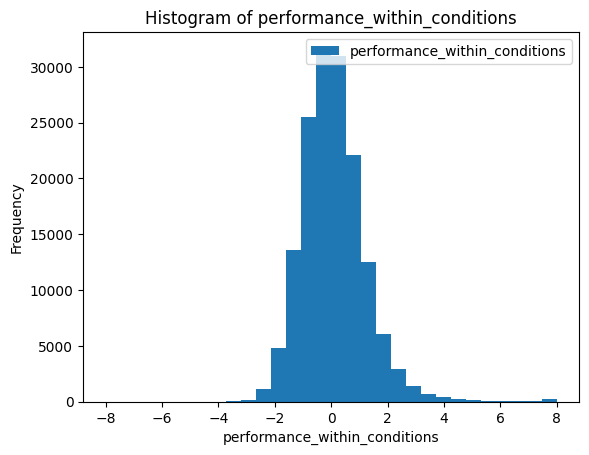

In [58]:
df.plot(kind="hist", y="performance_within_conditions", bins=30)
plt.xlabel("performance_within_conditions")
plt.title("Histogram of performance_within_conditions")
plt.show()

In [59]:
df['horse_name_id'] = df['horse_name'].str.split('(').str[1].str.strip(')')

In [60]:
cols = list(df.columns)
cols.insert(cols.index('horse_name') + 1, cols.pop(cols.index('horse_name_id')))
df = df[cols]

In [61]:
df.head()

,date,location,race_no,info,going,course,place,horse_number,horse_name,horse_name_id,jockey,trainer,weight,on_date_horse_weight,draw,length_behind_winner,running_position,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized,unique_id,performance_within_race,performance_within_conditions,top3,win,season
0,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",1,1.0,BEAUTIFUL CHOICE(CH130),CH130,K C Leung,Y S Tsui,119,1114.0,4.0,0.00,3321,1:35.78,5.6,1,264,Class 4,1600,60-40,TURF,2,1.0,95.78,1.005778,1.0,-0.847602,0.291676,Yes,1,1
1,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",2,9.0,LIVERBIRD(CE055),CE055,H W Lai,C S Shum,118,1125.0,8.0,0.20,6652,1:35.81,15.0,1,264,Class 4,1600,60-40,TURF,2,2.0,95.81,1.005778,1.0,-0.811788,0.197415,Yes,0,1
2,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",3,10.0,GREEN GLORY(CJ177),CJ177,W C Marwing,P F Yiu,118,1063.0,2.0,1.50,5563,1:36.04,3.6,1,264,Class 4,1600,60-40,TURF,2,3.0,96.04,1.005778,1.0,-0.537212,0.474648,Yes,0,1
3,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",4,4.0,BRILLIANT FLASH(CE042),CE042,O Doleuze,C Fownes,127,1144.0,9.0,1.75,101074,1:36.07,8.4,1,264,Class 4,1600,60-40,TURF,2,4.0,96.07,1.005778,1.0,-0.501398,0.296122,No,0,1
4,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",5,2.0,DR WELL(CD165),CD165,M L Yeung,C W Chang,118,1122.0,6.0,4.00,2235,1:36.41,9.5,1,264,Class 4,1600,60-40,TURF,2,5.0,96.41,1.005778,1.0,-0.095504,0.762097,No,0,1


In [62]:
df['top3_new'] = df['top3'].map({'Yes': 1, 'No': 0})

In [63]:
df['top3'] = df['top3_new']
df = df.drop(columns=['top3_new'])


#

## Recent Form Features
Now we create features giving information about the recent form of the horse (within one season)

In [64]:
df = df.sort_values(['horse_name', 'season', 'date'])

In [65]:
rolling_metrics = ['performance_within_race', 'performance_within_conditions', 'place_numeric']

In [66]:
season_group = ['horse_name', 'season']
df['races_in_season'] = df.groupby(season_group).cumcount() + 1

In [67]:
df['days_since_last_race_any'] = df.groupby('horse_name')['date'].diff().dt.days
df['days_since_last_race_same_season'] = df.groupby(season_group)['date'].diff().dt.days

In [68]:
# Compute rolling statistics per horse-season
window = 5
alpha = 0.5
for metric in rolling_metrics:
    shifted = df.groupby(season_group)[metric].shift(1)
    groups = shifted.groupby([df[c] for c in season_group])

    df[f'{metric}_rolling_mean_{window}'] = groups.transform(
        lambda s: s.rolling(window=window, min_periods=1).mean()
    )
    df[f'{metric}_rolling_median_{window}'] = groups.transform(
        lambda s: s.rolling(window=window, min_periods=1).median()
    )
    df[f'{metric}_rolling_count_{window}'] = groups.transform(
        lambda s: s.rolling(window=window, min_periods=1).count()
    )
    df[f'{metric}_ewa_{window}'] = groups.transform(
        lambda s: s.ewm(alpha=alpha, adjust=False, min_periods=1).mean()
    )

In [69]:
df.head(20)

,date,location,race_no,info,going,course,place,horse_number,horse_name,horse_name_id,jockey,trainer,weight,on_date_horse_weight,draw,length_behind_winner,running_position,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized,unique_id,performance_within_race,performance_within_conditions,top3,win,season,races_in_season,days_since_last_race_any,days_since_last_race_same_season,performance_within_race_rolling_mean_5,performance_within_race_rolling_median_5,performance_within_race_rolling_count_5,performance_within_race_ewa_5,performance_within_conditions_rolling_mean_5,performance_within_conditions_rolling_median_5,performance_within_conditions_rolling_count_5,performance_within_conditions_ewa_5,place_numeric_rolling_mean_5,place_numeric_rolling_median_5,place_numeric_rolling_count_5,place_numeric_ewa_5
108557,2020-09-27 00:00:00+08:00,Sha Tin,RACE 9 (63),Class 3 - 1200M - (80-60),GOOD,"TURF - ""A"" Course",13,5.0,A A AGILITY(D466),D466,N Callan,L Ho,125,1224.0,2.0,9.75,111213,1:10.51,131.0,9,63,Class 3,1200,80-60,TURF,0,13.0,70.51,0.989063,8555.0,2.314233,0.491585,0,0,12,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN
109228,2020-10-18 00:00:00+08:00,Sha Tin,RACE 10 (120),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""B+2"" Course",12,1.0,A A AGILITY(D466),D466,H T Mo,L Ho,125,1223.0,9.0,6.00,129712,1:23.02,163.0,10,120,Class 3,1400,80-60,TURF,2,12.0,83.02,0.996277,8612.0,1.267595,0.409312,0,0,12,2,21.0,21.0,2.314233,2.314233,1.0,2.314233,0.491585,0.491585,1.0,0.491585,13.000000,13.0,1.0,13.000000
110139,2020-11-14 00:00:00+08:00,Sha Tin,RACE 9 (192),Class 3 - 1400M - (85-60),GOOD,"TURF - ""C+3"" Course",14,13.0,A A AGILITY(D466),D466,H T Mo,L Ho,115,1253.0,7.0,9.00,11101214,1:22.99,320.0,9,192,Class 3,1400,85-60,TURF,3,14.0,82.99,0.990327,8684.0,2.516404,-0.088459,0,0,12,3,27.0,27.0,1.790914,1.790914,2.0,1.790914,0.450448,0.450448,2.0,0.450448,12.500000,12.5,2.0,12.500000
111013,2020-12-13 00:00:00+08:00,Sha Tin,RACE 6 (263),Class 3 - 1400M - (80-60),GOOD,"TURF - ""A"" Course",12,8.0,A A AGILITY(D466),D466,H T Mo,L Ho,118,1238.0,9.0,9.75,14131312,1:23.18,346.0,6,263,Class 3,1400,80-60,TURF,0,12.0,83.18,0.991299,8755.0,1.138766,0.051098,0,0,12,4,29.0,29.0,2.032744,2.314233,3.0,2.153659,0.270813,0.409312,3.0,0.180995,13.000000,13.0,3.0,13.250000
111917,2021-01-10 00:00:00+08:00,Sha Tin,RACE 9 (334),Class 3 - 1600M - (80-60),GOOD,"TURF - ""C"" Course",14,10.0,A A AGILITY(D466),D466,C Wong,L Ho,112,1222.0,14.0,21.50,321114,1:37.64,396.0,9,334,Class 3,1600,80-60,TURF,0,14.0,97.64,0.989292,8826.0,7.152026,1.330000,0,0,12,5,28.0,28.0,1.809249,1.790914,4.0,1.646213,0.215884,0.230205,4.0,0.116047,12.750000,12.5,4.0,12.625000
113380,2021-02-24 00:00:00+08:00,Happy Valley,RACE 2 (452),Class 4 - 1650M - (60-40),GOOD TO FIRM,"TURF - ""C+3"" Course",11,1.0,A A AGILITY(D466),D466,H T Mo,L Ho,130,1217.0,10.0,13.50,22211,1:42.71,150.0,2,452,Class 4,1650,60-40,TURF,3,11.0,102.71,1.003059,8944.0,3.631923,2.077032,0,0,12,6,45.0,45.0,2.877805,2.314233,5.0,4.399119,0.438707,0.409312,5.0,0.723023,13.000000,13.0,5.0,13.312500
119283,2021-10-20 00:00:00+08:00,Happy Valley,RACE 4 (107),Class 4 - 1200M - (60-40),GOOD TO FIRM,"TURF - ""C"" Course",11,2.0,A A AGILITY(D466),D466,M F Poon,L Ho,128,1247.0,11.0,9.00,121211,1:10.93,134.0,4,107,Class 4,1200,60-40,TURF,0,11.0,70.93,0.996666,9424.0,3.166403,0.591908,0,0,13,1,238.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN
119928,2021-11-10 00:00:00+08:00,Happy Valley,RACE 2 (160),Class 4 - 1650M - (60-40),GOOD,"TURF - ""B"" Course",12,6.0,A A AGILITY(D466),D466,H W Lai,L Ho,126,1251.0,12.0,14.25,1091012,1:42.21,213.0,2,160,Class 4,1650,60-40,TURF,0,12.0,102.21,0.997272,9477.0,2.344299,0.734015,0,0,13,2,21.0,21.0,3.166403,3.166403,1.0,3.166403,0.591908,0.591908,1.0,0.591908,11.000000,11.0,1.0,11.000000
120933,2021-12-12 00:00:00+08:00,Sha Tin,RACE 2 (244),Class 4 - 1400M - (60-40),GOOD,

<Axes: xlabel='performance_within_conditions_ewa_5', ylabel='Count'>

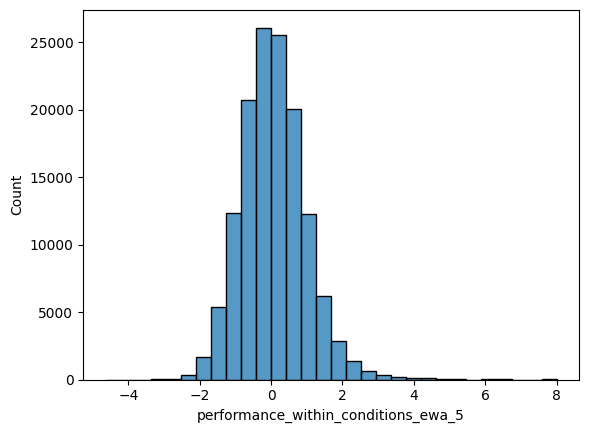

In [70]:
sns.histplot(data=df, x='performance_within_conditions_ewa_5', bins=30)

Now we calculate the trend / development of the horse during the races, and a confidence score for the recent developments

In [71]:
def rolling_slope(values):
    # Werte ohne NaNs betrachten
    clean = values.dropna()
    n = len(clean)
    if n < 2:
        return np.nan
    x = np.arange(n, dtype=float)
    y = clean.to_numpy(dtype=float)
    x_mean = x.mean()
    y_mean = y.mean()
    denom = ((x - x_mean) ** 2).sum()
    if denom == 0:
        return 0.0
    num = ((x - x_mean) * (y - y_mean)).sum()
    return num / denom

In [72]:
window = 5
alpha = 0.5
group_cols = ['horse_name', 'season']
rolling_metrics = ['performance_within_race', 'performance_within_conditions']

for metric in rolling_metrics:
    shifted = df.groupby(group_cols)[metric].shift(1)
    grouped_shifted = shifted.groupby([df[c] for c in group_cols])

    df[f'{metric}_trend'] = grouped_shifted.transform(
        lambda s: s.rolling(window=window, min_periods=2).apply(rolling_slope, raw=False)
    )

    df[f'{metric}_trend_confidence'] = (
        grouped_shifted.transform(lambda s: s.rolling(window=window, min_periods=1).count()) / window
    )

    df[f'{metric}_ewa_{window}'] = grouped_shifted.transform(
        lambda s: s.ewm(alpha=alpha, adjust=False, min_periods=1).mean()
    )

In [73]:
df.head(10)

,date,location,race_no,info,going,course,place,horse_number,horse_name,horse_name_id,jockey,trainer,weight,on_date_horse_weight,draw,length_behind_winner,running_position,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized,unique_id,performance_within_race,performance_within_conditions,top3,win,season,races_in_season,days_since_last_race_any,days_since_last_race_same_season,performance_within_race_rolling_mean_5,performance_within_race_rolling_median_5,performance_within_race_rolling_count_5,performance_within_race_ewa_5,performance_within_conditions_rolling_mean_5,performance_within_conditions_rolling_median_5,performance_within_conditions_rolling_count_5,performance_within_conditions_ewa_5,place_numeric_rolling_mean_5,place_numeric_rolling_median_5,place_numeric_rolling_count_5,place_numeric_ewa_5,performance_within_race_trend,performance_within_race_trend_confidence,performance_within_conditions_trend,performance_within_conditions_trend_confidence
108557,2020-09-27 00:00:00+08:00,Sha Tin,RACE 9 (63),Class 3 - 1200M - (80-60),GOOD,"TURF - ""A"" Course",13,5.0,A A AGILITY(D466),D466,N Callan,L Ho,125,1224.0,2.0,9.75,111213,1:10.51,131.0,9,63,Class 3,1200,80-60,TURF,0,13.0,70.51,0.989063,8555.0,2.314233,0.491585,0,0,12,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0
109228,2020-10-18 00:00:00+08:00,Sha Tin,RACE 10 (120),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""B+2"" Course",12,1.0,A A AGILITY(D466),D466,H T Mo,L Ho,125,1223.0,9.0,6.00,129712,1:23.02,163.0,10,120,Class 3,1400,80-60,TURF,2,12.0,83.02,0.996277,8612.0,1.267595,0.409312,0,0,12,2,21.0,21.0,2.314233,2.314233,1.0,2.314233,0.491585,0.491585,1.0,0.491585,13.000000,13.0,1.0,13.0000,NaN,0.2,NaN,0.2
110139,2020-11-14 00:00:00+08:00,Sha Tin,RACE 9 (192),Class 3 - 1400M - (85-60),GOOD,"TURF - ""C+3"" Course",14,13.0,A A AGILITY(D466),D466,H T Mo,L Ho,115,1253.0,7.0,9.00,11101214,1:22.99,320.0,9,192,Class 3,1400,85-60,TURF,3,14.0,82.99,0.990327,8684.0,2.516404,-0.088459,0,0,12,3,27.0,27.0,1.790914,1.790914,2.0,1.790914,0.450448,0.450448,2.0,0.450448,12.500000,12.5,2.0,12.5000,-1.046638,0.4,-0.082273,0.4
111013,2020-12-13 00:00:00+08:00,Sha Tin,RACE 6 (263),Class 3 - 1400M - (80-60),GOOD,"TURF - ""A"" Course",12,8.0,A A AGILITY(D466),D466,H T Mo,L Ho,118,1238.0,9.0,9.75,14131312,1:23.18,346.0,6,263,Class 3,1400,80-60,TURF,0,12.0,83.18,0.991299,8755.0,1.138766,0.051098,0,0,12,4,29.0,29.0,2.032744,2.314233,3.0,2.153659,0.270813,0.409312,3.0,0.180995,13.000000,13.0,3.0,13.2500,0.101086,0.6,-0.290022,0.6
111917,2021-01-10 00:00:00+08:00,Sha Tin,RACE 9 (334),Class 3 - 1600M - (80-60),GOOD,"TURF - ""C"" Course",14,10.0,A A AGILITY(D466),D466,C Wong,L Ho,112,1222.0,14.0,21.50,321114,1:37.64,396.0,9,334,Class 3,1600,80-60,TURF,0,14.0,97.64,0.989292,8826.0,7.152026,1.330000,0,0,12,5,28.0,28.0,1.809249,1.790914,4.0,1.646213,0.215884,0.230205,4.0,0.116047,12.750000,12.5,4.0,12.6250,-0.227759,0.8,-0.181923,0.8
113380,2021-02-24 00:00:00+08:00,Happy Valley,RACE 2 (452),Class 4 - 1650M - (60-40),GOOD TO FIRM,"TURF - ""C+3"" Course",11,1.0,A A AGILITY(D466),D466,H T Mo,L Ho,130,1217.0,10.0,13.50,22211,1:42.71,150.0,2,452,Class 4,1650,60-40,TURF,3,11.0,102.71,1.003059,8944.0,3.631923,2.077032,0,0,12,6,45.0,45.0,2.877805,2.314233,5.0,4.399119,0.438707,0.409312,5.0,0.723023,13.000000,13.0,5.0,13.3125,0.954676,1.0,0.131862,1.0
119283,2021-10-20 00:00:00+08:00,Happy Valley,RACE 4 (107),Class 4 - 1200M - (60-40),GOOD TO FIRM,"TURF - ""C"" Course",11,2.0,A A AGILITY(D466),D466,M F Poon,L Ho,128,1247.0,11.0,9.00,121211,1:10.93,134.0,4,107,Class 4,1200,60-40,TURF,0,11.0,70.93,0.996666,9424.0,3.166403,0.591908,0,0,13,1,238.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0
119928,2021-11-10 00:00:00+08:00,Happy Valley,RACE 2 (160),Class 4 - 1650M - (60-40),GOOD,"TURF - ""B"" Course",12,6.0,A A AGILITY(D466),D466,H W Lai,L Ho,126,1251.0,12.0,

<Axes: xlabel='performance_within_conditions_trend', ylabel='Count'>

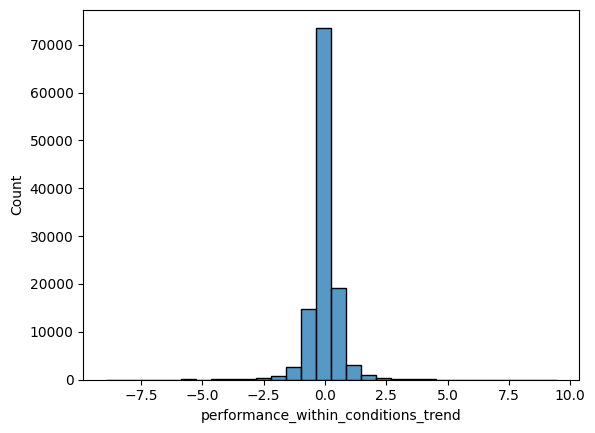

In [74]:
sns.histplot(data=df, x='performance_within_conditions_trend', bins=30)

Now we calculate a trend line for the weight of the horse within a season

In [75]:
def linear_reg_slope(series):
    values = series.dropna()
    n = len(values)
    if n < 2:
        return np.nan
    x = np.arange(n).reshape(-1, 1)
    model = LinearRegression().fit(x, values.values)
    return model.coef_[0]

In [76]:
window = 5
group_cols = ['horse_name', 'season']
# Compute trends over both the assigned race weight and the actual body
# weight on race day; the latter captures conditioning changes between starts.
weight_cols = ['weight', 'on_date_horse_weight']

In [77]:
for weight_col in weight_cols:
    df[f'{weight_col}_trend'] = (
        df.groupby(group_cols)[weight_col]
          .transform(lambda s: s.rolling(window=window, min_periods=2).apply(linear_reg_slope, raw=False))
    )

    df[f'{weight_col}_trend_confidence'] = (
        df.groupby(group_cols)[weight_col]
          .transform(lambda s: s.rolling(window=window, min_periods=1).count()) / window
    )

    # Direction = sign of the slope (-1 down, 0 flat, +1 up). NaN propagates
    # for horses with too few past weights to compute a slope.
    df[f'{weight_col}_trend_direction'] = np.sign(df[f'{weight_col}_trend'])

In [78]:
df.head(20)

,date,location,race_no,info,going,course,place,horse_number,horse_name,horse_name_id,jockey,trainer,weight,on_date_horse_weight,draw,length_behind_winner,running_position,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized,unique_id,performance_within_race,performance_within_conditions,top3,win,season,races_in_season,days_since_last_race_any,days_since_last_race_same_season,performance_within_race_rolling_mean_5,performance_within_race_rolling_median_5,performance_within_race_rolling_count_5,performance_within_race_ewa_5,performance_within_conditions_rolling_mean_5,performance_within_conditions_rolling_median_5,performance_within_conditions_rolling_count_5,performance_within_conditions_ewa_5,place_numeric_rolling_mean_5,place_numeric_rolling_median_5,place_numeric_rolling_count_5,place_numeric_ewa_5,performance_within_race_trend,performance_within_race_trend_confidence,performance_within_conditions_trend,performance_within_conditions_trend_confidence,weight_trend,weight_trend_confidence,weight_trend_direction,on_date_horse_weight_trend,on_date_horse_weight_trend_confidence,on_date_horse_weight_trend_direction
108557,2020-09-27 00:00:00+08:00,Sha Tin,RACE 9 (63),Class 3 - 1200M - (80-60),GOOD,"TURF - ""A"" Course",13,5.0,A A AGILITY(D466),D466,N Callan,L Ho,125,1224.0,2.0,9.75,111213,1:10.51,131.0,9,63,Class 3,1200,80-60,TURF,0,13.0,70.51,0.989063,8555.0,2.314233,0.491585,0,0,12,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.2,NaN,NaN,0.2,NaN
109228,2020-10-18 00:00:00+08:00,Sha Tin,RACE 10 (120),Class 3 - 1400M - (80-60),GOOD TO FIRM,"TURF - ""B+2"" Course",12,1.0,A A AGILITY(D466),D466,H T Mo,L Ho,125,1223.0,9.0,6.00,129712,1:23.02,163.0,10,120,Class 3,1400,80-60,TURF,2,12.0,83.02,0.996277,8612.0,1.267595,0.409312,0,0,12,2,21.0,21.0,2.314233,2.314233,1.0,2.314233,0.491585,0.491585,1.0,0.491585,13.000000,13.0,1.0,13.000000,NaN,0.2,NaN,0.2,0.0,0.4,0.0,-1.0,0.4,-1.0
110139,2020-11-14 00:00:00+08:00,Sha Tin,RACE 9 (192),Class 3 - 1400M - (85-60),GOOD,"TURF - ""C+3"" Course",14,13.0,A A AGILITY(D466),D466,H T Mo,L Ho,115,1253.0,7.0,9.00,11101214,1:22.99,320.0,9,192,Class 3,1400,85-60,TURF,3,14.0,82.99,0.990327,8684.0,2.516404,-0.088459,0,0,12,3,27.0,27.0,1.790914,1.790914,2.0,1.790914,0.450448,0.450448,2.0,0.450448,12.500000,12.5,2.0,12.500000,-1.046638,0.4,-0.082273,0.4,-5.0,0.6,-1.0,14.5,0.6,1.0
111013,2020-12-13 00:00:00+08:00,Sha Tin,RACE 6 (263),Class 3 - 1400M - (80-60),GOOD,"TURF - ""A"" Course",12,8.0,A A AGILITY(D466),D466,H T Mo,L Ho,118,1238.0,9.0,9.75,14131312,1:23.18,346.0,6,263,Class 3,1400,80-60,TURF,0,12.0,83.18,0.991299,8755.0,1.138766,0.051098,0,0,12,4,29.0,29.0,2.032744,2.314233,3.0,2.153659,0.270813,0.409312,3.0,0.180995,13.000000,13.0,3.0,13.250000,0.101086,0.6,-0.290022,0.6,-3.1,0.8,-1.0,7.2,0.8,1.0
111917,2021-01-10 00:00:00+08:00,Sha Tin,RACE 9 (334),Class 3 - 1600M - (80-60),GOOD,"TURF - ""C"" Course",14,10.0,A A AGILITY(D466),D466,C Wong,L Ho,112,1222.0,14.0,21.50,321114,1:37.64,396.0,9,334,Class 3,1600,80-60,TURF,0,14.0,97.64,0.989292,8826.0,7.152026,1.330000,0,0,12,5,28.0,28.0,1.809249,1.790914,4.0,1.646213,0.215884,0.230205,4.0,0.116047,12.750000,12.5,4.0,12.625000,-0.227759,0.8,-0.181923,0.8,-3.3,1.0,-1.0,1.1,1.0,1.0
113380,2021-02-24 00:00:00+08:00,Happy Valley,RACE 2 (452),Class 4 - 1650M - (60-40),GOOD TO FIRM,"TURF - ""C+3"" Course",11,1.0,A A AGILITY(D466),D466,H T Mo,L Ho,130,1217.0,10.0,13.50,22211,1:42.71,150.0,2,452,Class 4,1650,60-40,TURF,3,11.0,102.71,1.003059,8944.0,3.631923,2.077032,0,0,12,6,45.0,45.0,2.877805,2.314233,5.0,4.399119,0.438707,0.409312,5.0,0.723023,13.000000,13.0,5.0,13.312500,0.954676,1.0,0.131862,1.0,0.7,1.0,1.0,-4.3,1.0,-1.0
119283,2021-10-20 00:00:00+08:00,Happy Valley,RACE 4 (107),Class 4 - 1200M - (60-40),GOOD TO FIRM,"TURF - ""C"" Course",11,2.0,A A AGILITY(D466),D466,M F Poon,L Ho,128,1247.0,11.0,9.00,121211,1:10.93,134.0,4,10

In [79]:
len(df['horse_name_id'].unique())

8493

In [80]:
df_sorted = df.sort_values(['unique_id', 'place_numeric'])

In [81]:
df_sorted.head()

,date,location,race_no,info,going,course,place,horse_number,horse_name,horse_name_id,jockey,trainer,weight,on_date_horse_weight,draw,length_behind_winner,running_position,finish_time,win_odds,race_id_number,race_id_year,info_class,info_distance,info_rating,surface_type,rail_offset,place_numeric,finish_time_seconds,speed_normalized,unique_id,performance_within_race,performance_within_conditions,top3,win,season,races_in_season,days_since_last_race_any,days_since_last_race_same_season,performance_within_race_rolling_mean_5,performance_within_race_rolling_median_5,performance_within_race_rolling_count_5,performance_within_race_ewa_5,performance_within_conditions_rolling_mean_5,performance_within_conditions_rolling_median_5,performance_within_conditions_rolling_count_5,performance_within_conditions_ewa_5,place_numeric_rolling_mean_5,place_numeric_rolling_median_5,place_numeric_rolling_count_5,place_numeric_ewa_5,performance_within_race_trend,performance_within_race_trend_confidence,performance_within_conditions_trend,performance_within_conditions_trend_confidence,weight_trend,weight_trend_confidence,weight_trend_direction,on_date_horse_weight_trend,on_date_horse_weight_trend_confidence,on_date_horse_weight_trend_direction
0,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",1,1.0,BEAUTIFUL CHOICE(CH130),CH130,K C Leung,Y S Tsui,119,1114.0,4.0,0.00,3321,1:35.78,5.6,1,264,Class 4,1600,60-40,TURF,2,1.0,95.78,1.005778,1.0,-0.847602,0.291676,1,1,1,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.2,NaN,NaN,0.2,NaN
1,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",2,9.0,LIVERBIRD(CE055),CE055,H W Lai,C S Shum,118,1125.0,8.0,0.20,6652,1:35.81,15.0,1,264,Class 4,1600,60-40,TURF,2,2.0,95.81,1.005778,1.0,-0.811788,0.197415,1,0,1,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.2,NaN,NaN,0.2,NaN
2,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",3,10.0,GREEN GLORY(CJ177),CJ177,W C Marwing,P F Yiu,118,1063.0,2.0,1.50,5563,1:36.04,3.6,1,264,Class 4,1600,60-40,TURF,2,3.0,96.04,1.005778,1.0,-0.537212,0.474648,1,0,1,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.2,NaN,NaN,0.2,NaN
3,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",4,4.0,BRILLIANT FLASH(CE042),CE042,O Doleuze,C Fownes,127,1144.0,9.0,1.75,101074,1:36.07,8.4,1,264,Class 4,1600,60-40,TURF,2,4.0,96.07,1.005778,1.0,-0.501398,0.296122,0,0,1,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.2,NaN,NaN,0.2,NaN
4,2009-01-01 00:00:00+08:00,Sha Tin,RACE 1 (264),Class 4 - 1600M - (60-40),GOOD TO FIRM,"TURF - ""B+2"" Course",5,2.0,DR WELL(CD165),CD165,M L Yeung,C W Chang,118,1122.0,6.0,4.00,2235,1:36.41,9.5,1,264,Class 4,1600,60-40,TURF,2,5.0,96.41,1.005778,1.0,-0.095504,0.762097,0,0,1,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.2,NaN,NaN,0.2,NaN


In [82]:
df_sorted.to_csv('../data/HKHJ_Dataset_Feature_Engineered.csv', index=False)

### Further development ideas
-> Performance during last season (compared to others)